In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import glob

## Ingest data

In [2]:
# Find paths for all CSV files in the folder
file_paths = glob.glob("C:/Users/User/OneDrive/Personal Projects/Data Analytics/Supply chain bottlenecks/data/raw/*.csv")

# Create a dictionary of DataFrames using the file name as the key
dataframes_dict = {
    os.path.basename(path).replace(".csv", ""): pd.read_csv(path)
    for path in file_paths
}

# Mapping file names to desired database staging table names
stg_customers = dataframes_dict['olist_customers_dataset']
stg_orders = dataframes_dict['olist_orders_dataset']
stg_order_items = dataframes_dict['olist_order_items_dataset']
stg_order_payments = dataframes_dict['olist_order_payments_dataset']
stg_order_reviews = dataframes_dict['olist_order_reviews_dataset']
stg_products = dataframes_dict['olist_products_dataset']
stg_sellers = dataframes_dict['olist_sellers_dataset']
stg_geolocation = dataframes_dict['olist_geolocation_dataset']
stg_category_translation = dataframes_dict['product_category_name_translation']

## EDA

### Structural Assessment (by tables)

In [3]:
stg_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
stg_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [5]:
stg_customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [6]:
stg_customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [7]:
# Check if any customer_id is duplicated in the stg_customers table
duplicate_count = stg_customers['customer_id'].duplicated().sum()
print(f"Duplicate order IDs: {duplicate_count}")

Duplicate order IDs: 0


Column customer_zip_code_prefix is missing the leading zeros (e.g. 9790 -> 09790).

In [8]:
stg_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
stg_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [10]:
stg_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [50]:
stg_orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

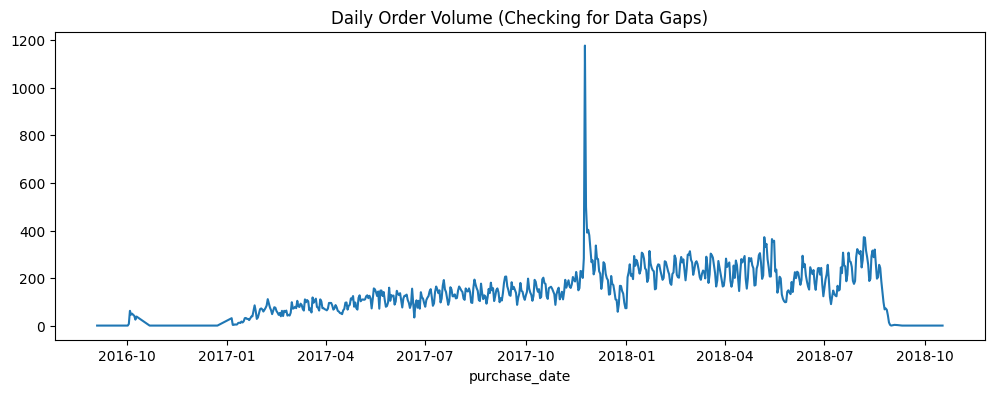

In [55]:
# Group by purchase date to see the daily trend
stg_orders['purchase_date'] = pd.to_datetime(stg_orders['order_purchase_timestamp']).dt.date
daily_orders = stg_orders.groupby('purchase_date').size()

plt.figure(figsize=(12, 4))
daily_orders.plot()
plt.title('Daily Order Volume (Checking for Data Gaps)')
plt.show()

In [12]:
# Check if any order_id is duplicated in the stg_orders table
duplicate_count = stg_orders['order_id'].duplicated().sum()
print(f"Duplicate order IDs: {duplicate_count}")

Duplicate order IDs: 0


In [13]:
# Create a flag indicating whether the delivery timestamp is null
stg_orders['is_delivery_null_1'] = stg_orders['order_delivered_carrier_date'].isnull()

# Cross-tabulate with order_status
status_cross_tab1 = pd.crosstab(stg_orders['order_status'], stg_orders['is_delivery_null_1'])
print(status_cross_tab1)

is_delivery_null_1  False  True 
order_status                    
approved                0      2
canceled               75    550
created                 0      5
delivered           96476      2
invoiced                0    314
processing              0    301
shipped              1107      0
unavailable             0    609


In [14]:
# Create a flag indicating whether the delivery timestamp is null
stg_orders['is_delivery_null_2'] = stg_orders['order_delivered_customer_date'].isnull()

# Cross-tabulate with order_status
status_cross_tab2 = pd.crosstab(stg_orders['order_status'], stg_orders['is_delivery_null_2'])
print(status_cross_tab2)

is_delivery_null_2  False  True 
order_status                    
approved                0      2
canceled                6    619
created                 0      5
delivered           96470      8
invoiced                0    314
processing              0    301
shipped                 0   1107
unavailable             0    609


In [15]:
# Create a flag indicating whether the delivery timestamp is null
stg_orders['is_delivery_null_3'] = stg_orders['order_delivered_carrier_date'].isnull()

# Cross-tabulate with order_status
status_cross_tab3 = pd.crosstab(stg_orders['order_status'], stg_orders['is_delivery_null_3'])
print(status_cross_tab3)

is_delivery_null_3  False  True 
order_status                    
approved                0      2
canceled               75    550
created                 0      5
delivered           96476      2
invoiced                0    314
processing              0    301
shipped              1107      0
unavailable             0    609


During the EDA phase, cross-tabulation exposed minor data integrity leaks:

Isolated 8 orders marked as delivered missing key destination timestamps. (Referring to stg_orders['order_delivered_customer_date'])

Isolated 6 orders marked as canceled that recorded a physical customer delivery date. (Referring to stg_orders['order_delivered_customer_date'])

Resolution: To protect relational integrity across the data warehouse, rows were preserved. However, robust conditional SQL (CASE WHEN) was implemented in the transformation tier to isolate these anomalies, preventing them from contaminating logistics duration metrics or confusing business end-users on the final Power BI dashboard.

Columns (order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date) need to convert to datetime.

In [16]:
stg_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [17]:
stg_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [18]:
stg_order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [19]:
stg_order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Column shipping_limit_date needs to be converted to datetime.

In [20]:
stg_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [21]:
stg_order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [22]:
stg_order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [23]:
stg_order_payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Table stg_order_payments is clean

In [24]:
stg_order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [25]:
stg_order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [26]:
stg_order_reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [27]:
stg_order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [28]:
# Check for Chronological Violations
# 1. Temporarily cast columns to datetime for the check
review_created = pd.to_datetime(stg_order_reviews['review_creation_date'])
review_answered = pd.to_datetime(stg_order_reviews['review_answer_timestamp'])

# 2. Filter for rows where the answer timestamp is BEFORE the creation date
chronological_errors = stg_order_reviews[review_answered < review_created]

# 3. Print the results
print(f"Total chronological anomalies found: {len(chronological_errors)}")
if len(chronological_errors) > 0:
    print(chronological_errors[['review_id', 'review_creation_date', 'review_answer_timestamp']].head())

Total chronological anomalies found: 0


Columns (review_creation_date, review_answer_timestamp) need to be converted to datetime.

In [29]:
stg_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [30]:
stg_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [31]:
stg_products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [32]:
stg_products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [33]:
print(stg_products[stg_products['product_weight_g'].isna()])

                             product_id product_category_name  \
8578   09ff539a621711667c43eba6a3bd8466                 bebes   
18851  5eb564652db742ff8f28759cd8d2652a                   NaN   

       product_name_lenght  product_description_lenght  product_photos_qty  \
8578                  60.0                       865.0                 3.0   
18851                  NaN                         NaN                 NaN   

       product_weight_g  product_length_cm  product_height_cm  \
8578                NaN                NaN                NaN   
18851               NaN                NaN                NaN   

       product_width_cm  
8578                NaN  
18851               NaN  


In [51]:
stg_products['product_category_name'].value_counts()

product_category_name
cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 73, dtype: int64

In [34]:
# Check if any product_id is duplicated in the stg_products table
duplicate_count = stg_products['product_id'].duplicated().sum()
print(f"Duplicate order IDs: {duplicate_count}")

Duplicate order IDs: 0


In [49]:
#Check for outliners
Q1_wei = stg_products['product_weight_g'].quantile(0.25)
Q3_wei = stg_products['product_weight_g'].quantile(0.75)
IQR_wei = Q3_wei - Q1_wei

Q1_l = stg_products['product_length_cm'].quantile(0.25)
Q3_l = stg_products['product_length_cm'].quantile(0.75)
IQR_l = Q3_l - Q1_l

Q1_h = stg_products['product_height_cm'].quantile(0.25)
Q3_h = stg_products['product_height_cm'].quantile(0.75)
IQR_h = Q3_h - Q1_h

Q1_wid = stg_products['product_width_cm'].quantile(0.25)
Q3_wid = stg_products['product_width_cm'].quantile(0.75)
IQR_wid = Q3_wid - Q1_wid

# Define boundaries
lower_bound_wei = Q1_wei - 1.5 * IQR_wei
upper_bound_wei = Q3_wei + 1.5 * IQR_wei

lower_bound_l = Q1_l - 1.5 * IQR_l
upper_bound_l = Q3_l + 1.5 * IQR_l

lower_bound_h = Q1_h - 1.5 * IQR_h
upper_bound_h = Q3_h + 1.5 * IQR_h

lower_bound_wid = Q1_wid - 1.5 * IQR_wid
upper_bound_wid = Q3_wid + 1.5 * IQR_wid

outliers_wei = stg_products[(stg_products['product_weight_g'] < lower_bound_wei) | (stg_products['product_weight_g'] > upper_bound_wei)]
outliers_l = stg_products[(stg_products['product_length_cm'] < lower_bound_l) | (stg_products['product_length_cm'] > upper_bound_l)]
outliers_h = stg_products[(stg_products['product_height_cm'] < lower_bound_h) | (stg_products['product_height_cm'] > upper_bound_h)]
outliers_wid = stg_products[(stg_products['product_width_cm'] < lower_bound_wid) | (stg_products['product_width_cm'] > upper_bound_wid)]
print(f"Number of outlier products by weight: {len(outliers_wei)}")
print(f"Number of outlier products by weight: {len(outliers_l)}")
print(f"Number of outlier products by weight: {len(outliers_h)}")
print(f"Number of outlier products by weight: {len(outliers_wid)}")

Number of outlier products by weight: 4551
Number of outlier products by weight: 1380
Number of outlier products by weight: 1892
Number of outlier products by weight: 912


All products have product id but some products are missing detailed information.

In [35]:
stg_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [36]:
stg_sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [37]:
stg_sellers.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [38]:
# Check if any seller_id is duplicated in the stg_sellers table
duplicate_count = stg_sellers['seller_id'].duplicated().sum()
print(f"Duplicate order IDs: {duplicate_count}")

Duplicate order IDs: 0


Column seller_zip_code_prefix is missing the leading zeros (e.g. 4195 -> 04195).

In [39]:
stg_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [40]:
stg_geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [41]:
stg_geolocation.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [42]:
stg_geolocation.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Column geolocation_zip_code_prefix is missing the leading zeros (e.g. 1037 -> 01037).

In [43]:
stg_category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [44]:
stg_category_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [45]:
stg_category_translation.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

Table stg_category_translation is clean

## Summary

### Table stg_customers
column customer_zip_code_prefix is missing leading zeros (e.g. 4195 -> 04195).

### Table stg_orders
During the EDA phase, cross-tabulation exposed minor data integrity leaks:

Isolated 8 orders marked as delivered missing key destination timestamps. (Referring to stg_orders['order_delivered_customer_date'])

Isolated 6 orders marked as canceled that recorded a physical customer delivery date. (Referring to stg_orders['order_delivered_customer_date'])

Resolution: To protect relational integrity across the data warehouse, rows were preserved. However, robust conditional SQL (CASE WHEN) was implemented in the transformation tier to isolate these anomalies, preventing them from contaminating logistics duration metrics or confusing business end-users on the final Power BI dashboard.

Columns (order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date) need to be converted to datetime.

### Table stg_order_items
Column shipping_limit_date needs to be converted to datetime.

### Table stg_order_payments
Table is clean.

### Table stg_order_reviews
Columns (review_creation_date, review_answer_timestamp) need to be converted to datetime.

### Table stg_products
Some products are missing the product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm

Resolution: Fill the text nulls with a descriptive placeholder like 'unknown', and fill the numeric metric nulls with 0.

### Table stg_sellers
Column seller_zip_code_prefix is missing the leading zeros (e.g. 4195 -> 04195).

### Table stg_geolocation
Column geolocation_zip_code_prefix is missing the leading zeros (e.g. 4195 -> 04195).

### Table stg_category_translation
Table is clean.

## Unified Data Quality Audit & Transformation Blueprint

Following a comprehensive Exploratory Data Analysis (EDA) across all 9 staging tables, data quality findings have been consolidated into four operational cleaning rules. These rules dictate the execution logic for the upcoming transformation tier.

### 1. Data Type & Schema Standardization
* **Temporal Fields:** Multiple crucial date columns are currently ingested as generic `object` (text string) types. The ingestion engine must explicitly cast the following fields to `DATETIME64`:
    * `stg_orders`: `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date`
    * `stg_order_items`: `shipping_limit_date`
    * `stg_order_reviews`: `review_creation_date`, `review_answer_timestamp`
* **Chronological Validation:** Logical checks confirmed that 100% of review entries satisfy temporal constraints ($Review\ Answer\ \ge\ Review\ Creation$), validating timeline continuity.

### 2. Ingestion/Padding Errors (Truncated Zip Codes)
* **The Issue:** Zip code columns were systematically evaluated as integers, causing truncation of leading zeros for regions starting with `0` (e.g., `4195` instead of `04195`).
* **The Fix:** String padding using `.str.zfill(5)` must be applied during initial ETL to preserve join stability across the warehouse. Affects:
    * `stg_customers.customer_zip_code_prefix`
    * `stg_sellers.seller_zip_code_prefix`
    * `stg_geolocation.geolocation_zip_code_prefix`

### 3. Missing Value & Imputation Strategy
* **`stg_products` Metadata Gaps:** Exactly 610 records are completely missing category names, description parameters, and photo tallies. Two records entirely lack physical dimensional attributes.
    * *Resolution:* To protect relational integrity during upcoming joins, text nulls will be imputed with `'unknown'`, and physical measurement nulls will be safely mapped to `0`.
* **`stg_order_reviews` Feedback Gaps:** Review comment text fields display up to 88% missing rates. These represent a standard customer choice to leave numerical ratings without written feedback.
    * *Resolution:* Retained as-is or mapped to a standard placeholder string (`'No Message'`) to ensure compatibility with downstream visualization engines.

### 4. Supply Chain & Operational Anomalies
Cross-tabulation profiling isolated distinct data integrity leaks where business statuses contradict physical delivery timestamps:
* **Invisible Deliveries:** Isolated **8 orders** marked as *delivered* that lack a destination timestamp (`order_delivered_customer_date` is null).
* **Ghost Deliveries:** Isolated **6 orders** finalized as *canceled* that nevertheless recorded a physical customer arrival timestamp.
* *Resolution:* Rows will be retained to safeguard transactional values. However, robust conditional conditional logic (`CASE WHEN`) will be hardcoded into the Fact table transformation layer to prevent these edge cases from skewing carrier transit time averages.